# Лабораторная работа №1

**1. Загрузка библиотек**

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import preprocessing

**2. Загрузка датасета**

In [28]:
data = pd.read_csv("~/university/bachelor-3/semester-1/machine-learning/lab1/marriage_longevity_master.csv")

**3. Удаление пропусков**

In [29]:
# Проверка на дубликаты и пропуски
print(data.isna().sum())

# Новый столбец + удаление years_to_divorce
data['long_lasting_marriage'] = ((data['years_to_divorce'] >= 8) | (data['years_married'] >= 8)).astype(int)

data = data.drop(columns=['years_to_divorce'])

marriage_id                      0
marriage_number                  0
age_at_marriage                  0
age_gap_years                    0
education_level                  0
household_income_usd             0
financial_stress                 0
both_employed                    0
cohabited_before                 0
premarital_counseling            0
child_before_marriage            0
n_children                       0
religious_attendance             0
criticism                        0
contempt                         0
defensiveness                    0
stonewalling                     0
repair_attempt_success           0
positive_negative_ratio          0
conflict_frequency_weekly        0
shared_activities_weekly         0
years_married                    0
years_to_divorce             24292
divorced                         0
dtype: int64


**4. Кодирование тектовых категориальных признаков**

In [30]:
data_1h = data.copy()
data_1h = pd.get_dummies(data_1h, columns=["education_level", "religious_attendance"], dtype=int)
data_1h.drop(columns=["education_level_less_than_hs", "religious_attendance_never"], inplace=True)
data_1h.head(10)

,marriage_id,marriage_number,age_at_marriage,age_gap_years,household_income_usd,financial_stress,both_employed,cohabited_before,premarital_counseling,child_before_marriage,...,years_married,divorced,long_lasting_marriage,education_level_bachelors,education_level_graduate,education_level_high_school,education_level_some_college,religious_attendance_monthly,religious_attendance_rarely,religious_attendance_weekly
0,MAR000000,1,36,6,68600.0,5.9,1,1,0,0,...,22.0,0,1,0,0,0,0,0,0,0
1,MAR000001,2,59,1,328800.0,0.0,1,1,0,0,...,15.5,0,1,0,0,0,1,0,0,0
2,MAR000002,2,44,1,139900.0,6.1,0,0,1,0,...,7.2,0,0,0,0,1,0,0,0,0
3,MAR000003,1,25,2,97600.0,5.9,1,1,1,0,...,13.5,0,1,1,0,0,0,0,1,0
4,MAR000004,2,29,3,98200.0,4.0,0,0,1,0,...,7.5,1,0,0,1,0,0,0,1,0
5,MAR000005,1,29,4,170700.0,6.2,1,0,1,0,...,7.4,0,0,0,1,0,0,0,1,0
6,MAR000006,1,34,1,149500.0,2.3,1,0,0,0,...,12.6,0,1,0,1,0,0,1,0,0
7,MAR000007,1,29,3,127100.0,4.3,1,1,0,0,...,20.3,0,1,0,0,0,1,1,0,0
8,MAR000008,1,31,1,55200.0,8.8,0,1,0,0,...,19.6,0,1,0,0,1,0,0,1,0
9,MAR000009,1,28,3,192000.0,2.7,1,1,0,0,...,5.3,1,0,0,0,0,1,0,1,0


**5. Нормализация**

In [31]:
data_1h_norm = data_1h.copy()

numeric_cols = ["age_at_marriage", "household_income_usd", "age_gap_years", "years_married"]

scaler = preprocessing.MinMaxScaler()
data_1h_norm[numeric_cols] = pd.DataFrame(scaler.fit_transform(data_1h_norm[numeric_cols]))
data_1h_norm.head(10)   

,marriage_id,marriage_number,age_at_marriage,age_gap_years,household_income_usd,financial_stress,both_employed,cohabited_before,premarital_counseling,child_before_marriage,...,years_married,divorced,long_lasting_marriage,education_level_bachelors,education_level_graduate,education_level_high_school,education_level_some_college,religious_attendance_monthly,religious_attendance_rarely,religious_attendance_weekly
0,MAR000000,1,0.384615,0.3750,0.100846,5.9,1,1,0,0,...,0.394495,0,1,0,0,0,0,0,0,0
1,MAR000001,2,0.826923,0.0625,0.541117,0.0,1,1,0,0,...,0.275229,0,1,0,0,0,1,0,0,0
2,MAR000002,2,0.538462,0.0625,0.221489,6.1,0,0,1,0,...,0.122936,0,0,0,0,1,0,0,0,0
3,MAR000003,1,0.173077,0.1250,0.149915,5.9,1,1,1,0,...,0.238532,0,1,1,0,0,0,0,1,0
4,MAR000004,2,0.250000,0.1875,0.150931,4.0,0,0,1,0,...,0.128440,1,0,0,1,0,0,0,1,0
5,MAR000005,1,0.250000,0.2500,0.273604,6.2,1,0,1,0,...,0.126606,0,0,0,1,0,0,0,1,0
6,MAR000006,1,0.346154,0.0625,0.237733,2.3,1,0,0,0,...,0.222018,0,1,0,1,0,0,1,0,0
7,MAR000007,1,0.250000,0.1875,0.199831,4.3,1,1,0,0,...,0.363303,0,1,0,0,0,1,1,0,0
8,MAR000008,1,0.288462,0.0625,0.078173,8.8,0,1,0,0,...,0.350459,0,1,0,0,1,0,0,1,0
9,MAR000009,1,0.230769,0.1875,0.309645,2.7,1,1,0,0,...,0.088073,1,0,0,0,0,1,0,1,0


**6. Очистка данных**

In [32]:
# Проверка на дубликаты
print(data.duplicated().sum())

0


Дубликатов нет, поэтому удалять ничего не нужно

**7. Диаграммы рассеяния**

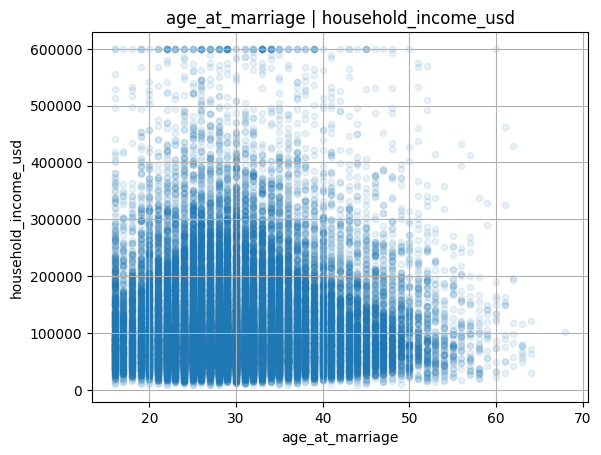

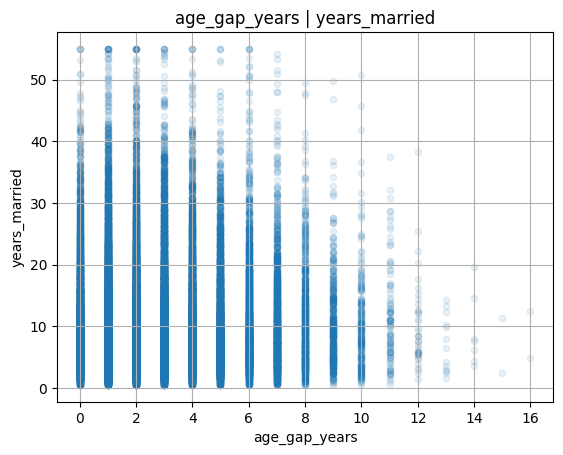

In [33]:
cols = [
    ["age_at_marriage", "household_income_usd"],
    ["age_gap_years", "years_married"],
]

for col in cols:
    data.plot(
        kind="scatter",
        x=col[0],
        y=col[1],
        alpha=0.1,
        grid=True,
    )
    plt.title(f"{col[0]} | {col[1]}")
    plt.show()

**8. Ящики с усами**

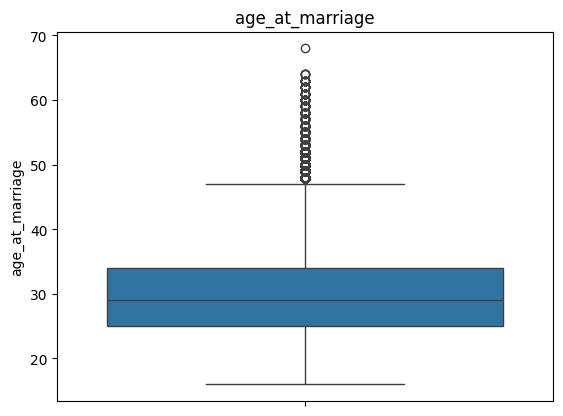

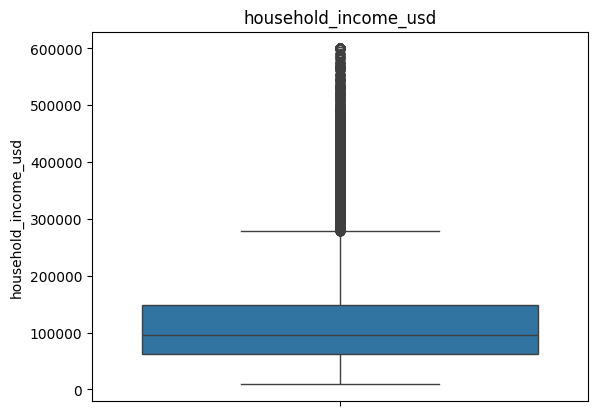

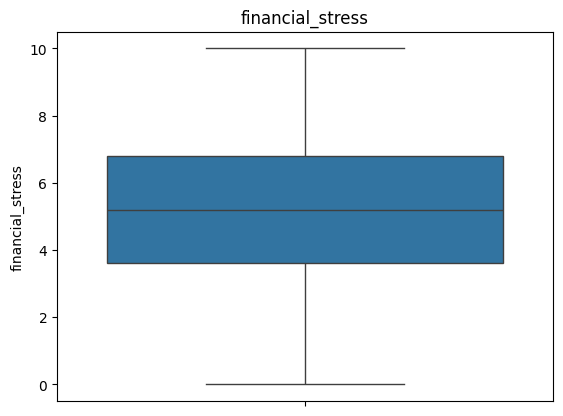

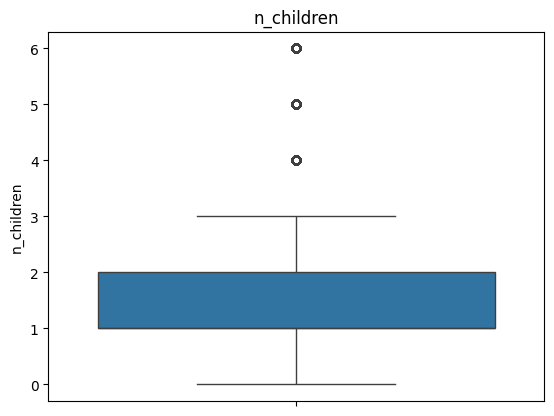

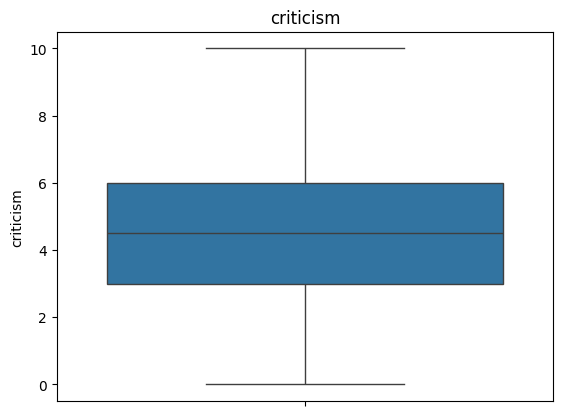

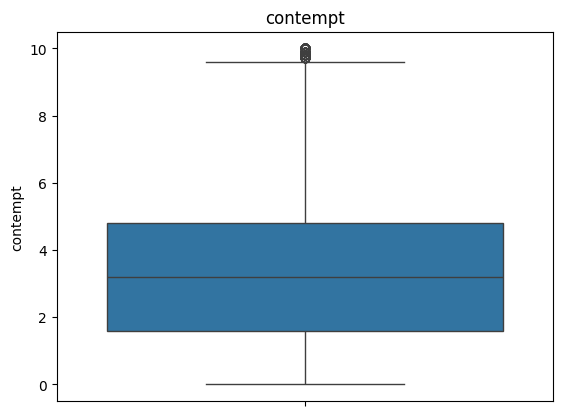

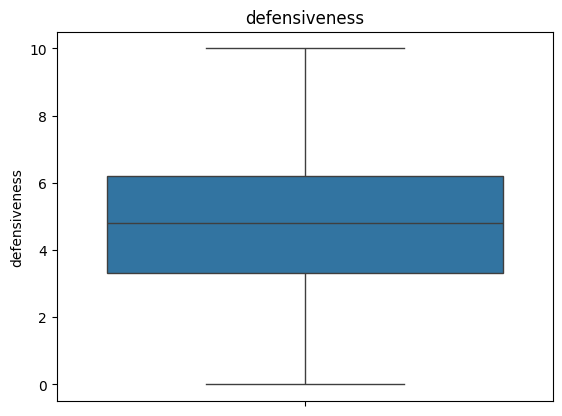

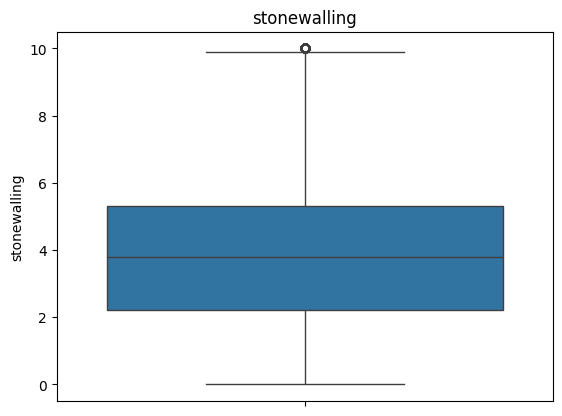

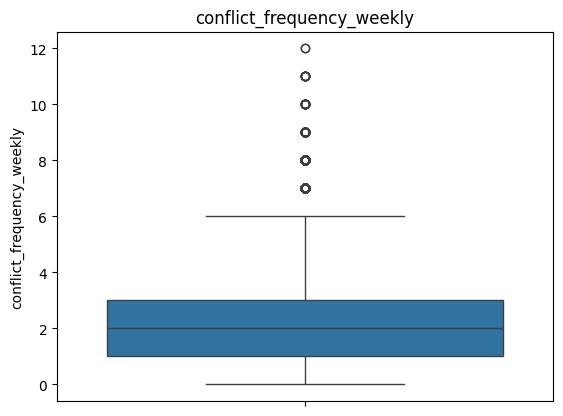

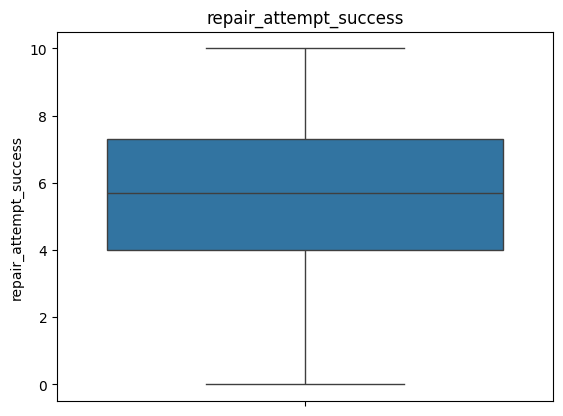

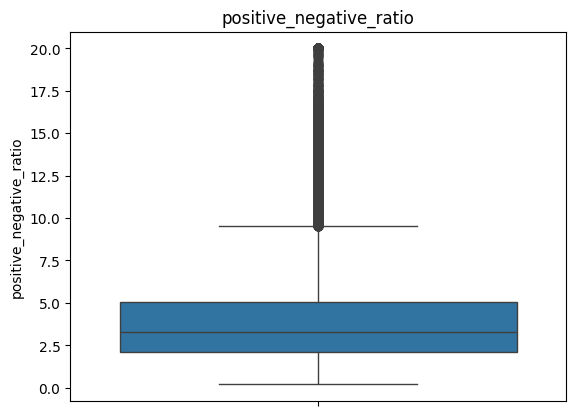

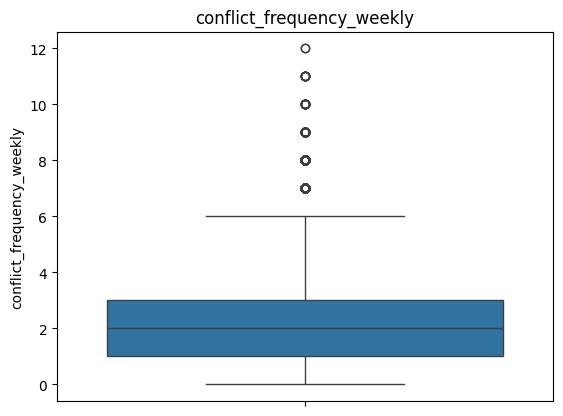

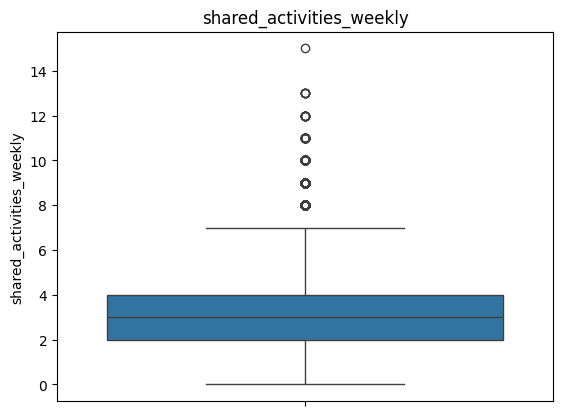

In [34]:
cols = [
    'age_at_marriage',
    'household_income_usd',
    'financial_stress',
    'n_children',
    'criticism',
    'contempt',
    'defensiveness',
    'stonewalling',
    'conflict_frequency_weekly',
    'repair_attempt_success',
    'positive_negative_ratio',
    'conflict_frequency_weekly',
    'shared_activities_weekly'
]

for col in cols:
    sns.boxplot(
        y=col,
        data=data,
    )
    plt.title(col)
    plt.show()

**9. Гистограммы**

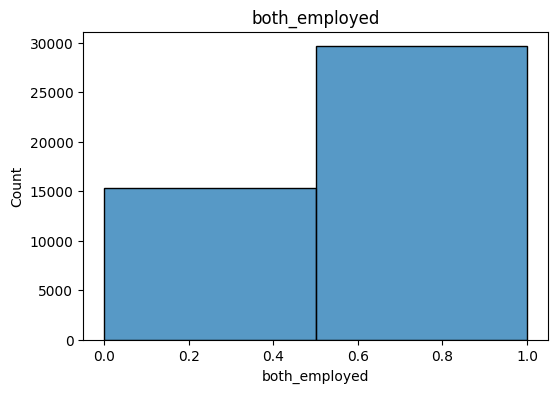

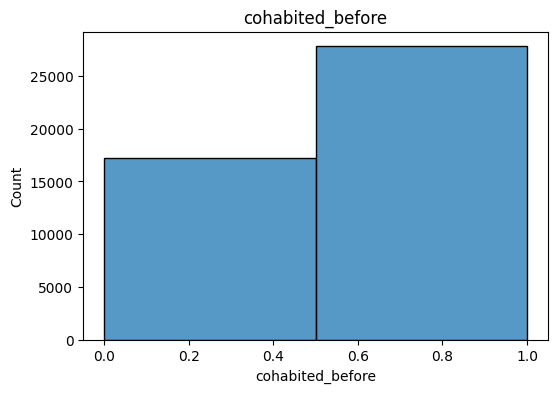

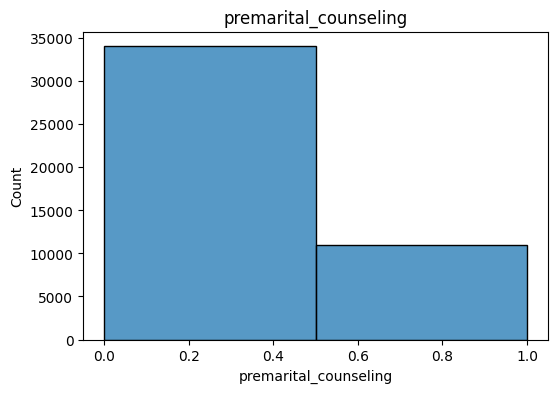

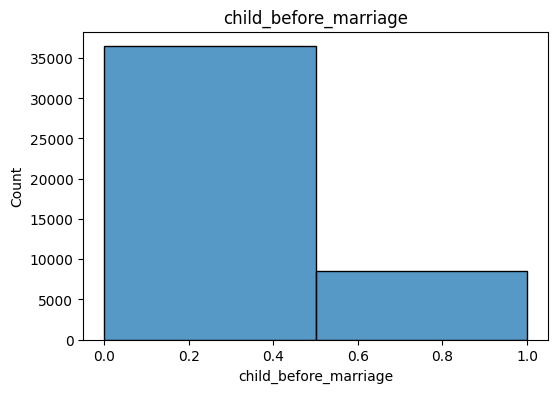

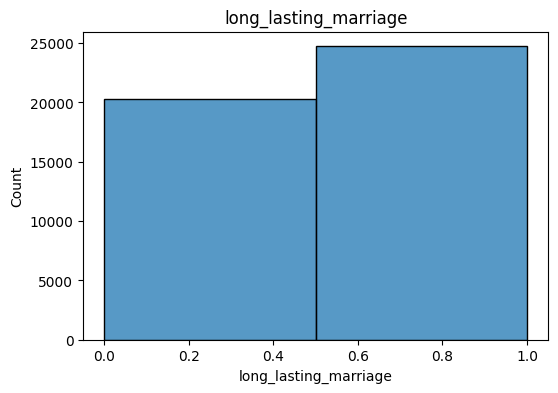

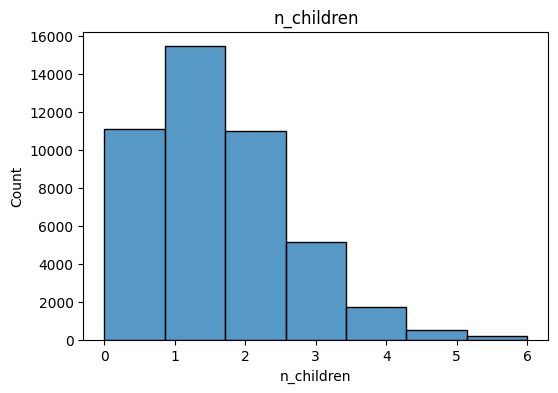

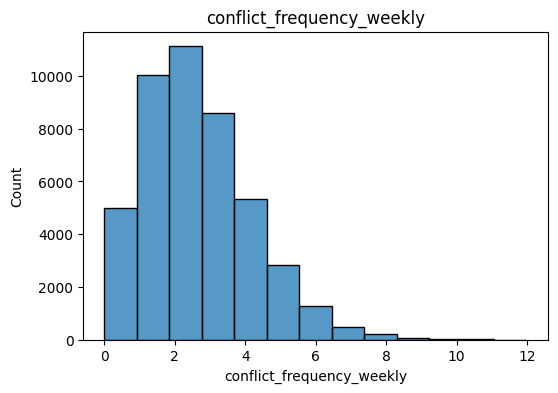

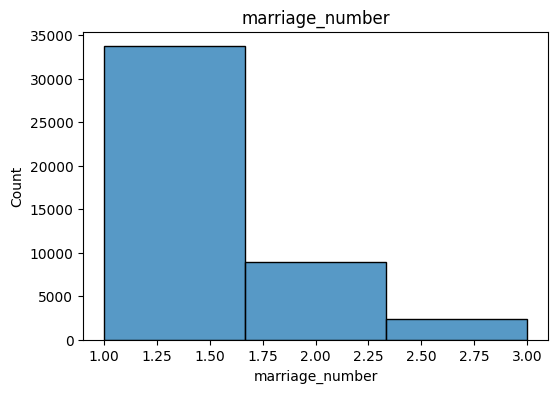

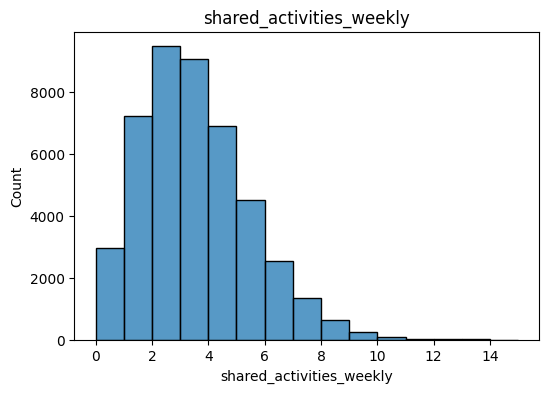

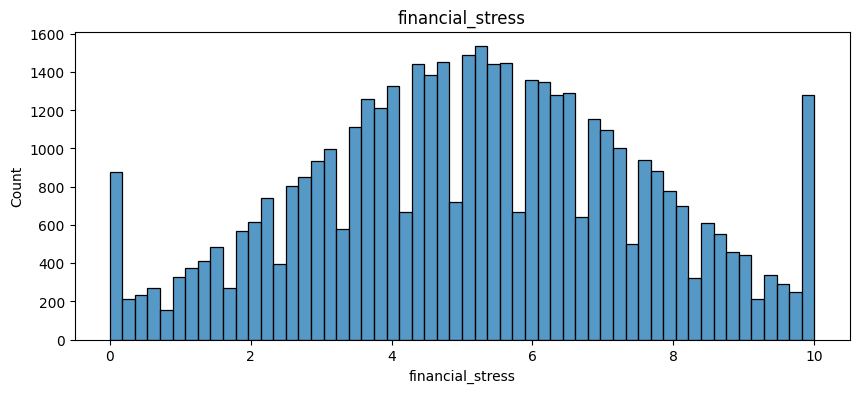

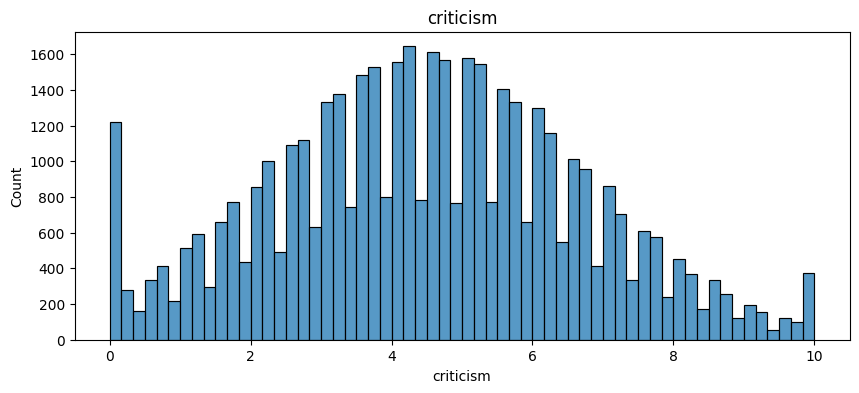

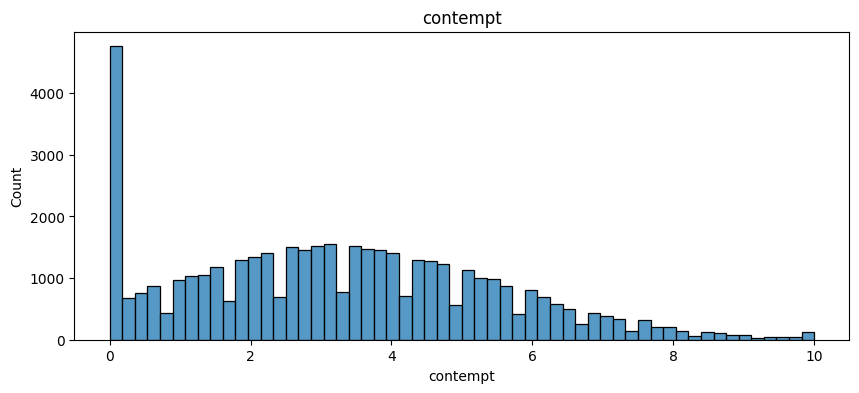

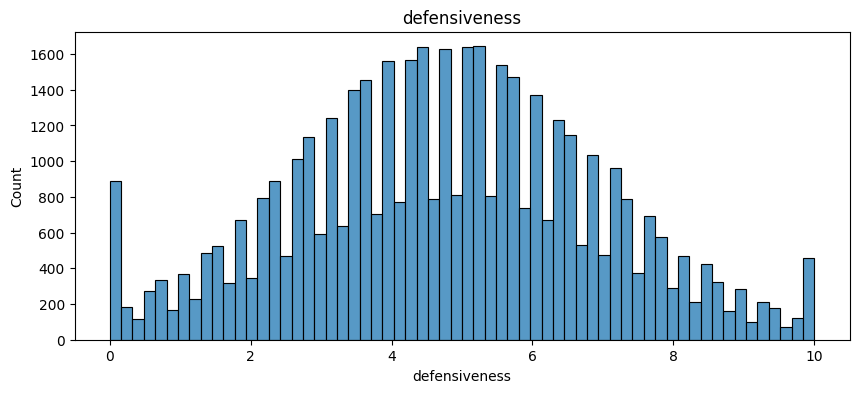

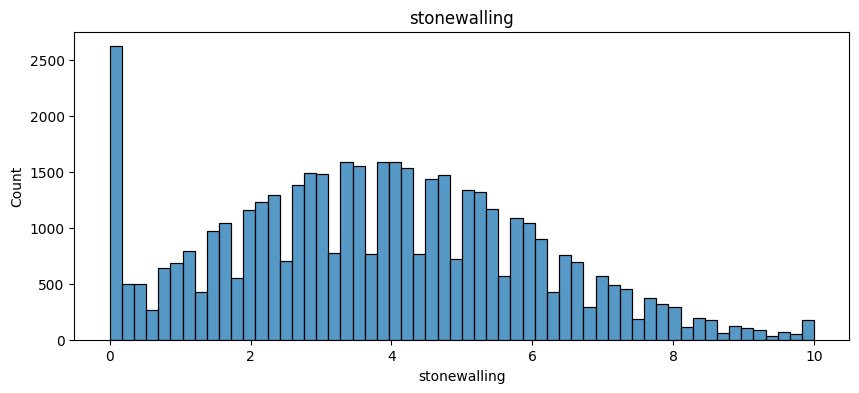

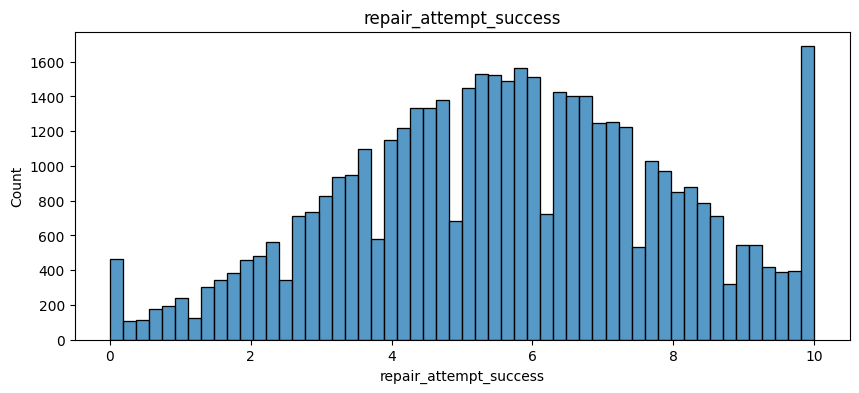

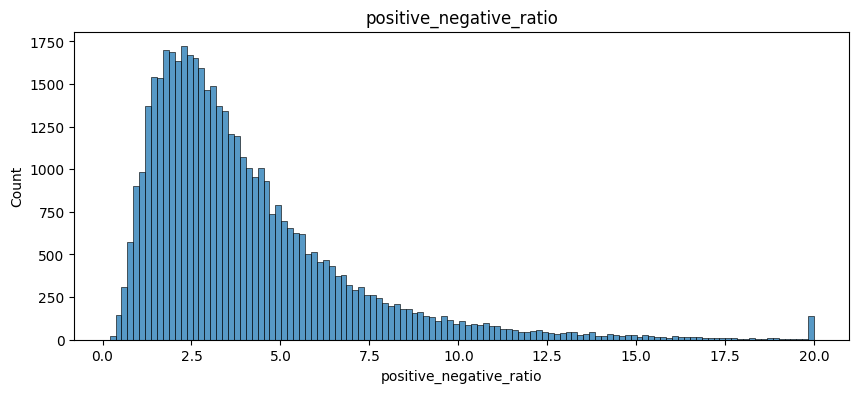

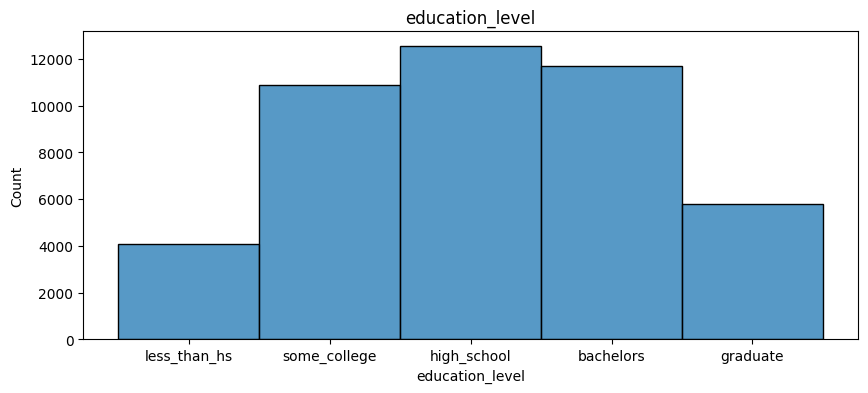

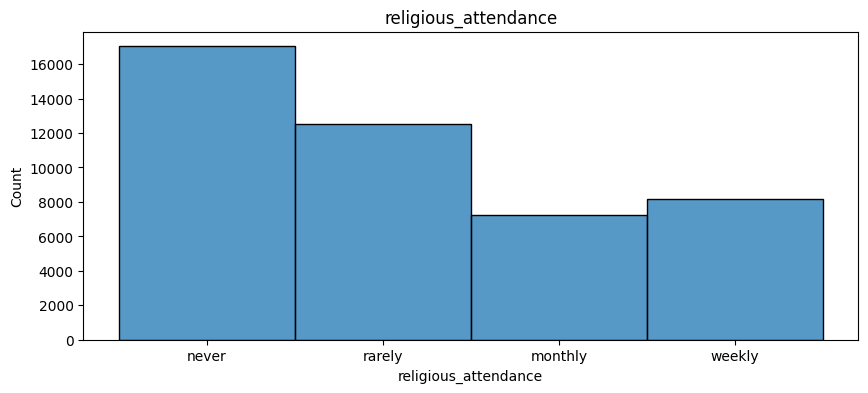

In [35]:
discrete_cols = ['both_employed', 'cohabited_before', 'premarital_counseling',
                 'child_before_marriage', 'long_lasting_marriage', 'n_children', 'conflict_frequency_weekly',
                 'marriage_number', 'shared_activities_weekly']

continuous_cols = ['financial_stress', 'criticism', 'contempt',
                   'defensiveness', 'stonewalling', 'repair_attempt_success',
                   'positive_negative_ratio',
                   'education_level', 'religious_attendance']

for col in discrete_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=data, x=col, bins=len(set(data[col])))
    plt.title(col)
    plt.show()

for col in continuous_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=data, x=col)
    plt.title(col)
    plt.show()


**10. Статистический анализ**

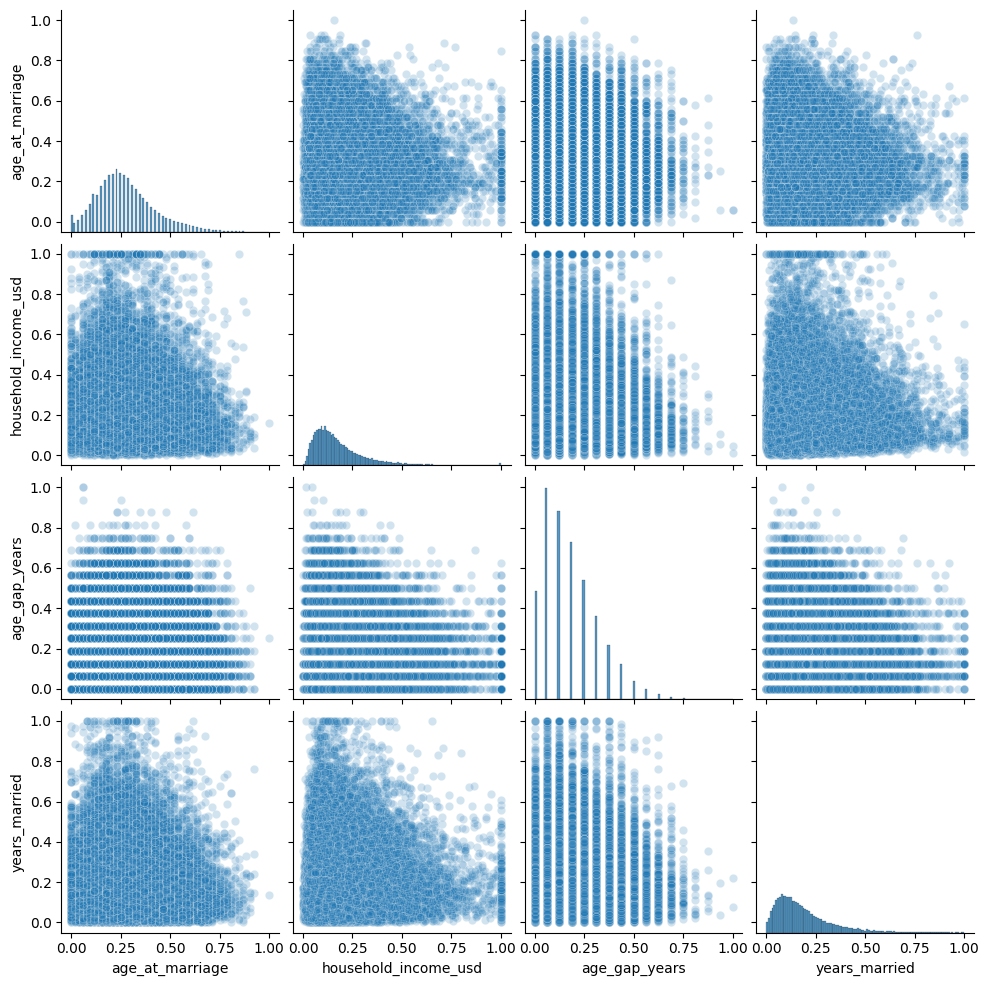

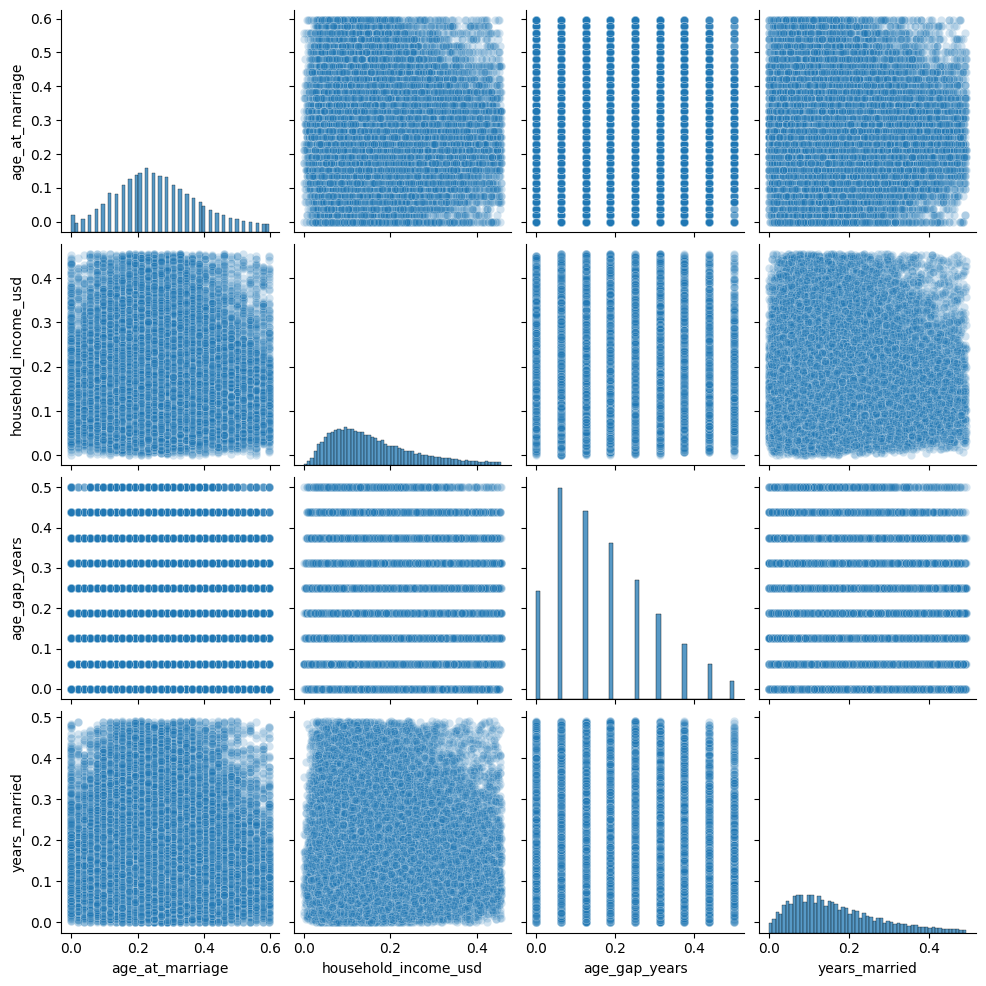

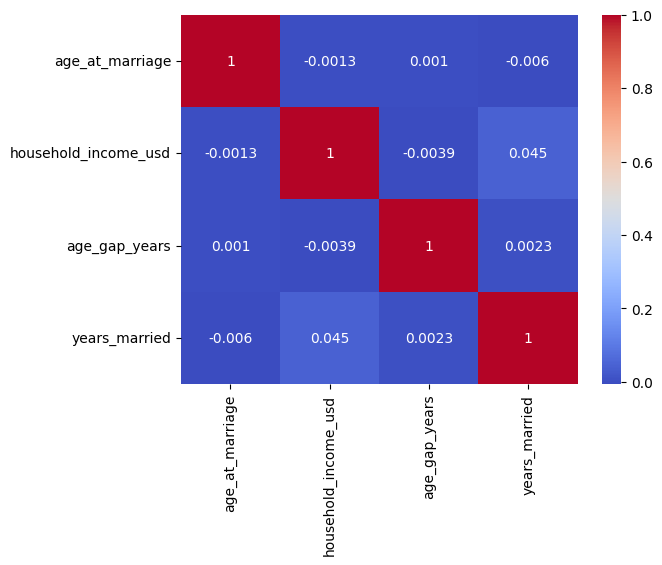

In [36]:
sns.pairplot(data_1h_norm[numeric_cols], plot_kws=dict(alpha=0.2))

def outliers_indices(col):
    q1, q3 = data_1h_norm[col].quantile([0.25, 0.75])
    iqr = q3 - q1

    return data_1h_norm[(data_1h_norm[col] < q1 - 1.5 * iqr) | (data_1h_norm[col] > q3 + 1.5 * iqr)].index

out = set()

for col in numeric_cols:
    out |= set(outliers_indices(col))

data_1h.drop(out, inplace=True)
data_1h.reset_index(drop=True, inplace=True)

data_1h_norm.drop(out, inplace=True)
data_1h_norm.reset_index(drop=True, inplace=True)

sns.pairplot(data_1h_norm[numeric_cols], plot_kws=dict(alpha=0.2))
plt.show()

sns.heatmap(data_1h_norm[numeric_cols].corr(method='spearman'), cmap="coolwarm", annot=True)
plt.show()

In [37]:
stat_cols = ["dispersion", "variation", "excess"]

stat_funcs = pd.DataFrame(
    columns=[
        "dispersion",
        "variation",
        "excess",
    ],
    index=data_1h[numeric_cols].columns,
)

stat_funcs["dispersion"] = data_1h[numeric_cols].var(ddof=0)
stat_funcs["variation"] = (data_1h[numeric_cols].std() / data_1h[numeric_cols].mean()) * 100
stat_funcs['excess'] = data_1h[numeric_cols].kurt()

stat_funcs

,dispersion,variation,excess
age_at_marriage,4.526257e+01,22.785437,-0.245148
household_income_usd,3.338761e+09,55.446130,0.146702
age_gap_years,4.007736e+00,72.997784,-0.301916
years_married,3.531904e+01,61.732261,0.046147
